# MODELADO - EVALUACIÓN

In [2]:
#librerias necesarias
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import pickle

In [23]:
sys.path.insert(0, '../src/')
from src.funciones import evaluate_and_sort_models, search_hyperparameters, evaluation_metrics, matriz_confusion

In [24]:
sys.path.insert(0, '../')
from src.parametros import logistic_regression, svc, knn, decision_tree, random_forest, adaboost, gradient_boosting, hyperparameters

In [3]:
#cargo de datos
dataTC= pd.read_csv('../data/feature/dataTC_feature.csv')
dataTC

,id,cat__contacto_celular,num__cons_conf_idx,cat__mes_may,num__emp_var_rate,cat__mes_otro,num__euribor3m,num__no_contactos,num__dias_ultima_camp,cat__contacto_telefono fijo,num__cons_price_idx,cat__resultado_anterior_otro,num__nr_employed,num__edad,cat__resultado_anterior_sin contacto,y
0,1,0,0.60251,1,0.937500,0,0.962728,0.000000,1.000000,1,0.991835,0,0.859848,0.506494,1,0
1,2,0,0.60251,1,0.937500,0,0.962728,0.000000,1.000000,1,0.991835,0,0.859848,0.246753,1,0
2,3,0,0.60251,1,0.937500,0,0.962728,0.000000,1.000000,1,0.991835,0,0.859848,0.285714,1,0
3,4,0,0.60251,1,0.937500,0,0.962728,0.000000,1.000000,1,0.991835,0,0.859848,0.493506,1,0
4,7,0,0.60251,1,0.937500,0,0.962728,0.000000,1.000000,1,0.991835,0,0.859848,0.090909,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23094,32963,1,0.00000,0,0.479167,1,0.203608,0.166667,0.009009,0,1.000000,1,0.000000,0.142857,0,0
23095,32964,1,0.00000,0,0.479167,1,0.203608,0.000000,1.000000,0,1.000000,0,0.000000,0.363636,1,0
23096,32965,1,0.00000,0,0.479167,1,0.203608,0.000000,1.000000,0,1.000000,0,0.000000,0.493506,1,0
23097,32966,1,0.00000,0,0.479167,1,0.203608,0.000000,1.000000,0,1.000000,0,0.000000,0.337662,1,1


In [4]:
#guardado de id para posterior uso
ids = dataTC['id'].copy()
dataTC.drop(columns=['id'], inplace=True)

In [5]:
#separacion de datos en caracteristicas y etiqueta
X= dataTC.drop("y", axis=1)
y= dataTC["y"]

Balanceo de variable objetivo

In [7]:
#distribucion de clases original
print("Distribución original de clases:", Counter(y))

Distribución original de clases: Counter({0: 20509, 1: 2590})


In [8]:
#aplicación de SMOTE
smote = SMOTE(sampling_strategy=0.7, random_state=42)
X, y_balanceado = smote.fit_resample(X, y)

In [9]:
#distribucion de clases balanceada
print("Distribución balanceada de clases:", Counter(y_balanceado))

Distribución balanceada de clases: Counter({0: 20509, 1: 14356})


Modelado

In [10]:
#separacion de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test= train_test_split(X, y_balanceado, test_size=0.25, random_state=0, shuffle= True, stratify=y_balanceado) 

In [12]:
#modelos básicos 
basic_models = [
    ('Logistic Regression', LogisticRegression(C=logistic_regression['C'], solver=logistic_regression['solver'], max_iter=logistic_regression['max_iter'], random_state=logistic_regression['random_state'])),
    ('SVM', SVC(C=svc['C'], kernel=svc['kernel'], gamma=svc['gamma'], random_state=svc['random_state'])),
    ('KNN', KNeighborsClassifier(n_neighbors=knn['n_neighbors'], weights=knn['weights'], algorithm=knn['algorithm'], leaf_size=knn['leaf_size'])),
    ('Decision Tree', DecisionTreeClassifier(max_depth=decision_tree['max_depth'], min_samples_split=decision_tree['min_samples_split'], min_samples_leaf=decision_tree['min_samples_leaf'], random_state=decision_tree['random_state']))
]

#modelos de ensamble
ensemble_models = [
    ('Random Forest', RandomForestClassifier(n_estimators=random_forest['n_estimators'], max_depth=random_forest['max_depth'], min_samples_split=random_forest['min_samples_split'], random_state=random_forest['random_state'])),
    ('AdaBoost', AdaBoostClassifier(n_estimators=adaboost['n_estimators'], learning_rate=adaboost['learning_rate'], random_state=adaboost['random_state'])),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=gradient_boosting['n_estimators'], learning_rate=gradient_boosting['learning_rate'], max_depth=gradient_boosting['max_depth'], random_state=gradient_boosting['random_state']))
]


In [13]:
#evaluacion y ordenamiento de modelos
basic_model_scores = evaluate_and_sort_models(basic_models, X_train, y_train)
ensemble_model_scores = evaluate_and_sort_models(ensemble_models, X_train, y_train)

In [14]:
#resultado modelos de básicos
print("modelos básicos (ordenados por Recall):")
for name, score in basic_model_scores:
    print(f"{name}: {score}")

modelos básicos (ordenados por Recall):
KNN: 0.7929671072845672
SVM: 0.7418994805394474
Decision Tree: 0.7376450238552057
Logistic Regression: 0.7349563385147292


In [15]:
#resultado modelos de ensamble
print("modelos de ensamble (ordenados por Recall):")
for name, score in ensemble_model_scores:
    print(f"{name}: {score}")

modelos de ensamble (ordenados por Recall):
Gradient Boosting: 0.8128108379953416
AdaBoost: 0.7414722603433811
Random Forest: 0.7396793789467326


In [16]:
#optimizacion de hiperparametros
optimization = search_hyperparameters(X_train, y_train, hyperparameters)
optimization

{'KNeighborsClassifier': (KNeighborsClassifier(algorithm='brute', weights='distance'),
  GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
               param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                           'leaf_size': [30, 40, 50], 'n_neighbors': [5, 10, 15],
                           'weights': ['uniform', 'distance']},
               refit='recall',
               scoring=['balanced_accuracy', 'precision', 'recall', 'f1'])),
 'AdaBoostClassifier': (AdaBoostClassifier(learning_rate=1, n_estimators=150),
  GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
               param_grid={'learning_rate': [0.1, 1, 10],
                           'n_estimators': [50, 100, 150]},
               refit='recall',
               scoring=['balanced_accuracy', 'precision', 'recall', 'f1'])),
 'GradientBoostingClassifier': (GradientBoostingClassifier(learning_rate=1, max_depth=5, n_estimators=150),
  GridSearchCV(cv=5, estimator=Gr

In [17]:
#modelos hiperparametrizados
kneighbors_model, kneighbors_grid_search = optimization['KNeighborsClassifier']
adaboost_model, adaboost_grid_search = optimization['AdaBoostClassifier']
gradientboosting_model, gradientboosting_grid_search = optimization['GradientBoostingClassifier']

In [18]:
#diccionario de modelos optimizados
optimization_results = {
    'KNeighborsClassifier': (kneighbors_model, kneighbors_grid_search),
    'AdaBoostClassifier': (adaboost_model, adaboost_grid_search),
    'GradientBoostingClassifier': (gradientboosting_model, gradientboosting_grid_search)
}

Evaluación de desempeño de los algoritmos con los datos de entrenamiento

In [19]:
#evaluacion en entranmiento de modelos hiperparametrizados
metrics_df, _ = evaluation_metrics(optimization_results, X_test, y_test)
metrics_df

,Modelo,precision,recall,balanced_accuracy,f1_score
3,GradientBoostingClassifier,0.914886,0.834400,0.890024,0.872763
1,KNeighborsClassifier,0.843634,0.717191,0.812044,0.775243
2,AdaBoostClassifier,0.790507,0.608990,0.748029,0.687926


Matriz de Confusión para KNeighborsClassifier:


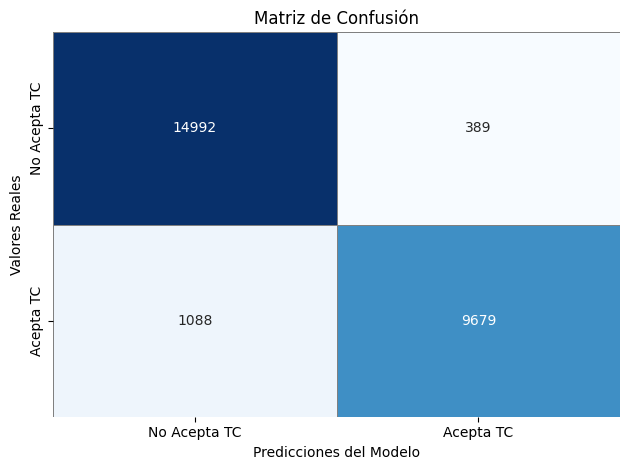

Matriz de Confusión para AdaBoostClassifier:


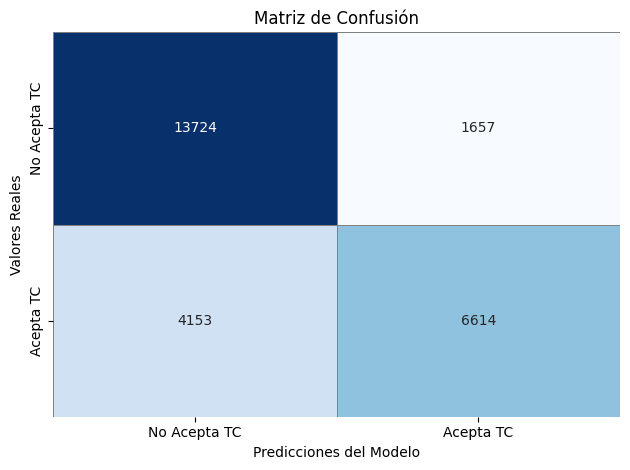

Matriz de Confusión para GradientBoostingClassifier:


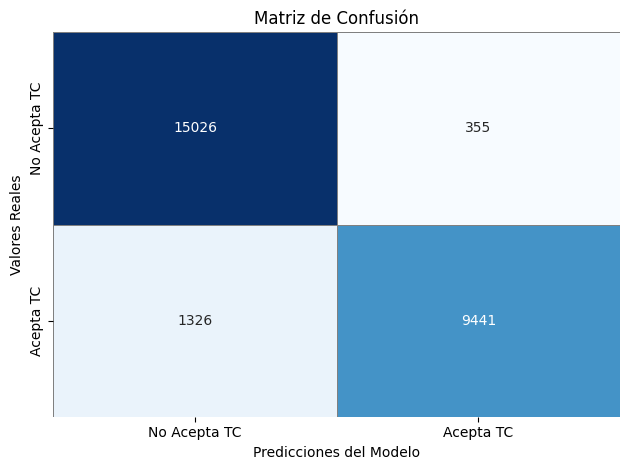

In [20]:
#matriz de confusión
for model_name, (model, _) in optimization.items():
    figura = matriz_confusion(model, X_train, y_train)
    print(f"Matriz de Confusión para {model_name}:")
    plt.show(figura)


Evaluación de desempeño del algoritmo con los datos de prueba

In [25]:
#evaluacion en prueba de modelos hiperparametrizados
_, predictions_df = evaluation_metrics(optimization_results, X_test, y_test)
predictions_df

,Modelo,precision,recall,balanced_accuracy,f1_score
1,KNeighborsClassifier,0.847729,0.738367,0.822772,0.789278
2,AdaBoostClassifier,0.780183,0.592366,0.737778,0.673424
3,GradientBoostingClassifier,0.909119,0.822235,0.882354,0.863497


Matriz de Confusión para KNeighborsClassifier:


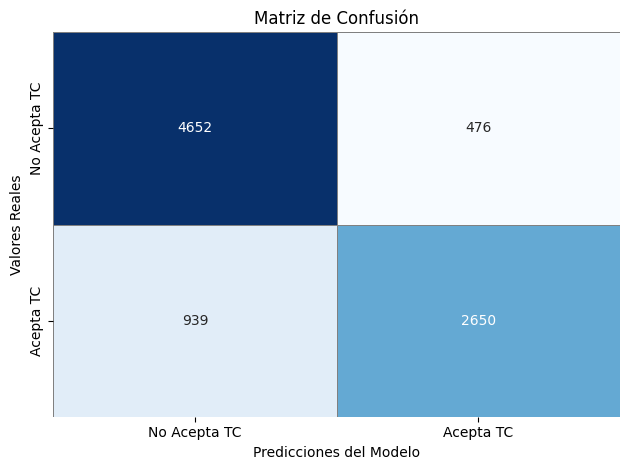

Matriz de Confusión para AdaBoostClassifier:


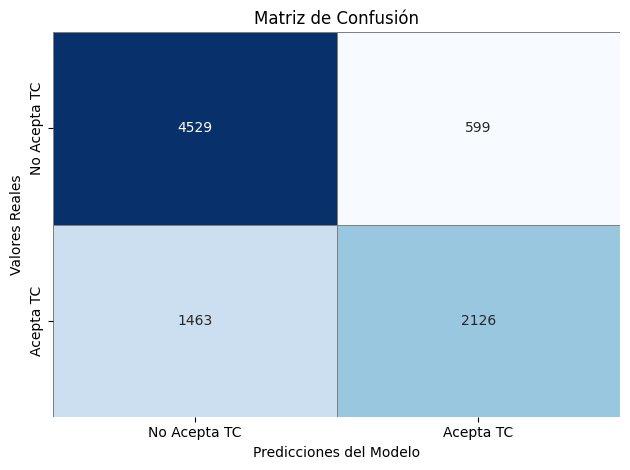

Matriz de Confusión para GradientBoostingClassifier:


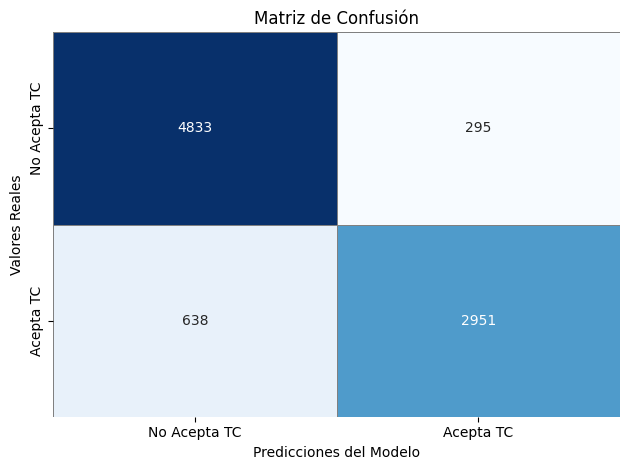

In [22]:
#matriz de confusión
for model_name, (model, _) in optimization.items():
    figura = matriz_confusion(model, X_test, y_test)
    print(f"Matriz de Confusión para {model_name}:")
    plt.show(figura)

Mejor modelo

In [34]:
best_model = optimization['GradientBoostingClassifier'][0]
with open('../data/results/best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [11]:
X_test.to_csv('../data/results/X_test.csv', index=False)